# 2.2 Q2 — Comparing two chunking strategies

In Q1, fixed-size chunking cut the transcript by counting tokens, blind to what was being said, and overlap could not fix it. Here I compare two strategies whose boundaries follow the **structure** or **meaning** of the speech instead:

- **Strategy A — sentence-boundary chunking:** never cut inside a sentence; pack whole sentences into chunks up to a size limit.
- **Strategy B — semantic chunking:** embed each sentence and cut where the meaning of consecutive sentences shifts.

**Test transcript.** A short synthetic lecture with punctuation roughly as Whisper would produce it. It has two topics (the thermal exhaust port, then the shield generator) and a **digression** about the reactor placed *between* the port's introduction (sentences 0–1) and its explanation (sentences 5–6). The explanation refers to the port only as "it".

**Test query in mind:** *"What are the key vulnerabilities of the thermal exhaust port?"* A good chunking should keep the port's introduction and explanation together, and keep the shield generator separate.

In [1]:
import re
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")

transcript = (
    "Okay so um today we are going to look at the thermal exhaust port. "
    "It is one of the the key weak points of the whole station. "
    "But before I explain why, let me just recall what we did last week. "
    "Last week we talked about the reactor and how it powers everything. "
    "The reactor sits right at the center of the station. "
    "So coming back, it is a small opening, only about two meters wide. "
    "And it leads straight to the core, so a single shot can reach the reactor. "
    "Alright, now let us move on to the shield generator. "
    "The shield generator is on the moon below, not on the station itself. "
    "If you take it down, the whole station loses its protection."
)

# split at whitespace that follows . ? or ! (the lookbehind keeps the punctuation)
sentences = re.split(r'(?<=[.?!])\s+', transcript.strip())
for i, s in enumerate(sentences):
    print(i, s)

0 Okay so um today we are going to look at the thermal exhaust port.
1 It is one of the the key weak points of the whole station.
2 But before I explain why, let me just recall what we did last week.
3 Last week we talked about the reactor and how it powers everything.
4 The reactor sits right at the center of the station.
5 So coming back, it is a small opening, only about two meters wide.
6 And it leads straight to the core, so a single shot can reach the reactor.
7 Alright, now let us move on to the shield generator.
8 The shield generator is on the moon below, not on the station itself.
9 If you take it down, the whole station loses its protection.


## Strategy A — Sentence-boundary chunking

**(a) What decides where a chunk starts and ends?**
Sentence boundaries. The transcript is first split into whole sentences, then sentences are packed into a chunk until adding the next one would exceed a token limit. In a real pipeline, sentence ends come from the punctuation added by the ASR model, or from **pauses** in Whisper's timestamps.

**(b) Why is it better suited to spoken transcripts than fixed-size chunking?**
It never cuts mid-thought. Speakers naturally pause at the end of a thought, so this uses a signal speech *does* have (timing, restored punctuation) to replace one it lacks (clean written structure). Chunks always begin and end on complete sentences.

In [2]:
def sentence_chunks(sentences, max_tokens):
    chunks, current, current_len = [], [], 0
    for s in sentences:
        n = len(enc.encode(s))
        if current and current_len + n > max_tokens:   # adding s would overflow
            chunks.append(" ".join(current))            # close current chunk
            current, current_len = [], 0                # start a new one
        current.append(s)
        current_len += n
    if current:                                         # save the last chunk
        chunks.append(" ".join(current))
    return chunks

for max_tokens in [40, 60]:
    print(f"===== max_tokens = {max_tokens} =====")
    for i, c in enumerate(sentence_chunks(sentences, max_tokens)):
        print(f"--- chunk {i} ({len(enc.encode(c))} tokens) ---\n{c}")

===== max_tokens = 40 =====
--- chunk 0 (29 tokens) ---
Okay so um today we are going to look at the thermal exhaust port. It is one of the the key weak points of the whole station.
--- chunk 1 (40 tokens) ---
But before I explain why, let me just recall what we did last week. Last week we talked about the reactor and how it powers everything. The reactor sits right at the center of the station.
--- chunk 2 (33 tokens) ---
So coming back, it is a small opening, only about two meters wide. And it leads straight to the core, so a single shot can reach the reactor.
--- chunk 3 (40 tokens) ---
Alright, now let us move on to the shield generator. The shield generator is on the moon below, not on the station itself. If you take it down, the whole station loses its protection.
===== max_tokens = 60 =====
--- chunk 0 (58 tokens) ---
Okay so um today we are going to look at the thermal exhaust port. It is one of the the key weak points of the whole station. But before I explain why, let me just

### Results — Strategy A

**The improvement:** no sentence is ever cut in half. Chunk sizes are uneven (29–40 tokens at a limit of 40; 28–58 at 60) because whole sentences are packed rather than cutting at exactly N tokens.

**The failure at `max_tokens = 40`:**

| Chunk | Content | Problem |
|---|---|---|
| 0 | Port introduction ("key weak points") | No explanation |
| 1 | Reactor digression | — |
| 2 | "**it** is a small opening… leads straight to the core" | The explanation, but the port is never named: **orphan context** |
| 3 | Shield generator (all three sentences) | Clean — but only because it happened to fit |

**Worse at `max_tokens = 60`:** chunk 1 mixes three topics (the reactor, the port explanation, and the transition to the shield generator). Its embedding becomes a blurred average of all three, and because it contains the words "shield generator", it could be retrieved for shield questions instead of chunk 2, which holds the actual facts.

**(c) Where Strategy A still fails:**
It keeps sentences whole but is **blind to topic**. Changing a single number (40 → 60) completely rearranged which ideas ended up together, and neither setting kept the port's introduction with its explanation. Whether related sentences land in the same chunk depends on the size setting, not on meaning. It would also break on hesitation pauses mid-sentence ("the… uh… exhaust port"), which create false sentence breaks, and on fast speakers who rarely pause, producing long run-ons.

## Strategy B — Semantic (embedding-based) chunking

**(a) What decides where a chunk starts and ends?**
A drop in meaning-similarity between neighbouring sentences. Every sentence is converted into an embedding (a vector representing its meaning). While consecutive sentences discuss the same thing, their embeddings are similar; when the similarity drops sharply, the topic has likely changed, and a boundary is placed there.

Instead of hand-picking a similarity threshold, I cut at the **lowest X% of similarities** in the transcript (a percentile breakpoint, the same idea used by LangChain's `SemanticChunker`), so the threshold adapts to each transcript.

**(b) Why is it better suited to spoken transcripts?**
Lectures drift between topics with no headings or paragraphs to mark the change. Semantic chunking detects topic shifts from the **content itself**, so it does not depend on speaking pace, filler words, or formatting.

*Note:* Strategy B is built on top of Strategy A's sentence splitting; the comparison is really "sentences grouped by size" versus "sentences grouped by meaning".

In [5]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu
%pip install sentence-transformers matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached setuptools-78.1.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.3/196.3 MB 9.8 MB/s  0:00:20s eta 0:00:0136m0:00:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached setuptools-78.1.0-py3-none-any.whl (1.3 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torch]━━━━━ 6/7 [torch][fsspec]

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached hf_xet-1.6.0-cp38-abi3-manylin

In [11]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")               # small, fast sentence-embedding model
emb = model.encode(sentences, normalize_embeddings=True)       # unit-length vectors -> dot product = cosine similarity
print(emb.shape)                                               # (number of sentences, 384)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 13081.80it/s]


(10, 384)


In [12]:
# similarity between each sentence and the next one
sims = np.sum(emb[:-1] * emb[1:], axis=1)
for i, s in enumerate(sims):
    print(f"sentence {i} -> {i+1}: {s:.2f}")

sentence 0 -> 1: 0.18
sentence 1 -> 2: 0.09
sentence 2 -> 3: 0.25
sentence 3 -> 4: 0.52
sentence 4 -> 5: 0.13
sentence 5 -> 6: 0.21
sentence 6 -> 7: 0.23
sentence 7 -> 8: 0.60
sentence 8 -> 9: 0.36


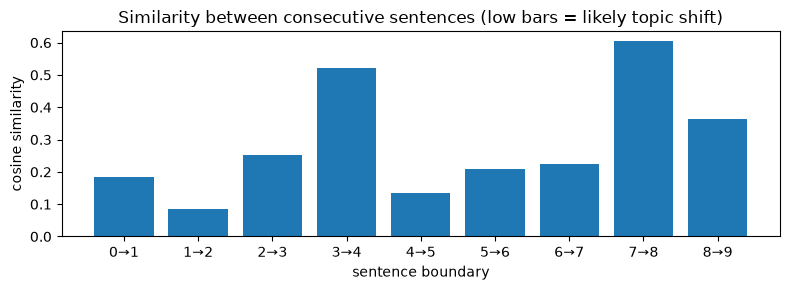

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.bar([f"{i}→{i+1}" for i in range(len(sims))], sims)
plt.ylabel("cosine similarity")
plt.xlabel("sentence boundary")
plt.title("Similarity between consecutive sentences (low bars = likely topic shift)")
plt.tight_layout()
plt.show()

In [14]:
def semantic_chunks(sentences, sims, threshold):
    chunks, current = [], [sentences[0]]
    for i, s in enumerate(sims):
        if s < threshold:                    # meaning shifted -> cut here
            chunks.append(" ".join(current))
            current = []
        current.append(sentences[i + 1])
    chunks.append(" ".join(current))         # save the last chunk
    return chunks

for pct in [20, 40]:
    threshold = np.percentile(sims, pct)
    print(f"===== cut at lowest {pct}% of similarities (threshold {threshold:.2f}) =====")
    for i, c in enumerate(semantic_chunks(sentences, sims, threshold)):
        print(f"--- chunk {i} ({len(enc.encode(c))} tokens) ---\n{c}")

===== cut at lowest 20% of similarities (threshold 0.16) =====
--- chunk 0 (29 tokens) ---
Okay so um today we are going to look at the thermal exhaust port. It is one of the the key weak points of the whole station.
--- chunk 1 (40 tokens) ---
But before I explain why, let me just recall what we did last week. Last week we talked about the reactor and how it powers everything. The reactor sits right at the center of the station.
--- chunk 2 (73 tokens) ---
So coming back, it is a small opening, only about two meters wide. And it leads straight to the core, so a single shot can reach the reactor. Alright, now let us move on to the shield generator. The shield generator is on the moon below, not on the station itself. If you take it down, the whole station loses its protection.
===== cut at lowest 40% of similarities (threshold 0.21) =====
--- chunk 0 (15 tokens) ---
Okay so um today we are going to look at the thermal exhaust port.
--- chunk 1 (14 tokens) ---
It is one of the the key w

### Side-by-side check

 I check automatically whether any chunk contains **both** the port's introduction and its explanation.

In [15]:
def report(name, chunks):
    together = any("thermal exhaust port" in c and "small opening" in c for c in chunks)
    sizes = [len(enc.encode(c)) for c in chunks]
    print(f"{name:<18} | chunks={len(chunks)} | sizes={sizes} | intro + explanation together: {together}")

report("A: max 40", sentence_chunks(sentences, 40))
report("A: max 60", sentence_chunks(sentences, 60))
for pct in [20, 40]:
    report(f"B: lowest {pct}%", semantic_chunks(sentences, sims, np.percentile(sims, pct)))

A: max 40          | chunks=4 | sizes=[29, 40, 33, 40] | intro + explanation together: False
A: max 60          | chunks=3 | sizes=[58, 56, 28] | intro + explanation together: False
B: lowest 20%      | chunks=3 | sizes=[29, 40, 73] | intro + explanation together: False
B: lowest 40%      | chunks=5 | sizes=[15, 14, 40, 16, 57] | intro + explanation together: False


### Results — Strategy B

### Results — Strategy B

**What the similarity scores show:**

| Boundary | Similarity | What actually happens there |
|---|---|---|
| 1→2 | **0.09** (lowest) | Entering the digression |
| 4→5 | **0.13** | Returning from the digression ("so coming back") |
| 0→1 | 0.18 | *Same topic* — "It is one of the key weak points" |
| 5→6 | 0.21 | *Same topic* — "And it leads straight to the core" |
| 6→7 | 0.23 | **Real topic change** to the shield generator |

**1. The digression was detected precisely.** The two lowest similarities are exactly the entry and exit of the digression, so at both thresholds the reactor digression became its own clean chunk which strategy A never achieved.

**2. The digression trap occurred.** Because it cut on both sides of the digression, the explanation ("it is a small opening…") was separated from "thermal exhaust port". The side-by-side check is `False` at both thresholds.

**3. The real topic change was missed.** The switch to the shield generator (0.23) scored *higher* than two same-topic boundaries (0.18 and 0.21). The cause is that each sentence is embedded **in isolation**: a sentence like "It is one of the key weak points" contains nothing that tells the model what "it" refers to, so same-topic sentences using pronouns look unrelated. Sentence-level similarity largely reflects shared vocabulary, not shared topic — and spoken explanations rely heavily on pronouns.

**4. The threshold produces opposite failures.**
- **Lowest 20%** (too few cuts): the final chunk is 73 tokens and mixes the port's explanation with the entire shield-generator topic. Semantic chunking has no size limit, so chunks can grow unchecked.
- **Lowest 40%** (too many cuts): "It is one of the key weak points" becomes a 14-token chunk on its own — a pure orphan — and the explanation is split in two, with "And it leads straight to the core" attached to the shield-generator chunk.

**(c) Where Strategy B still fails:**
- **The digression trap.** A digression is a genuine change of topic, so semantic chunking correctly cuts at it — and in doing so separates a topic's introduction from an explanation that resumes afterwards.
- **Pronouns and references.** Sentences embedded in isolation lose what "it" and "this" refer to, so same-topic sentences can appear dissimilar (observed above).
- **No size control.** Without a cap, chunks can grow large and mix topics (the 73-token chunk).
- **Tiny sentences** ("Okay so.", "Right.") produce embeddings with little meaning, making scores noisy.
- **ASR errors** distort sentence meaning and therefore the embeddings.
- **Threshold sensitivity.** Too low merges topics, too high fragments them, and the right value differs per transcript.

*Caveat:* this is a 10-sentence synthetic transcript with only 9 similarity values, so the percentile thresholds are coarse. The results illustrate failure mechanisms rather than measure performance; a proper evaluation at scale is designed in Q3.


## Comparison

| | Strategy A — Sentence boundaries | Strategy B — Semantic similarity |
|---|---|---|
| **Boundary signal** | End of a sentence (punctuation / pauses), plus a size limit | Drop in embedding similarity between neighbouring sentences |
| **Strength on speech** | Never cuts mid-thought; cheap; uses pause timing speech naturally has | Finds topic shifts from content alone; independent of pace and formatting |
| **Main weakness** | Blind to topic — which ideas end up together depends on the size setting | Digressions trigger cuts that orphan resumed explanations; noisy on tiny or mis-transcribed sentences |
| **Cost** | Tokenizer only | One embedding per sentence (plus the usual embedding per chunk) |
| **On this transcript** | Intro and explanation separated at both sizes | Detected the digression precisely, but still separated intro and explanation; missed the real topic change; 73-token mixed chunk at 20%, fragmented orphans at 40%|

### A limitation both strategies share

Both strategies produce **contiguous** chunks: each chunk is an unbroken stretch of the transcript. In this lecture, the port's introduction (sentences 0–1) and its explanation (sentences 5–6) are **not adjacent** — the digression sits between them. So no contiguous chunking can put them together without also swallowing the digression. Fixing this needs something beyond choosing better cut points, for example attaching surrounding context to each chunk, or retrieving small chunks but passing the larger section they came from to the LLM. This motivates the pipeline design in Q3.

### Which would I use?

Neither strategy alone is enough, but they fail in complementary ways, so I would combine them:

1. **Sentence segmentation first** (Strategy A's strength): restore sentence boundaries using ASR punctuation and pause timing, so no chunk ever cuts mid-thought.
2. **Semantic boundaries on top** (Strategy B's strength): cut where meaning shifts, but compare **windows of neighbouring sentences** rather than single sentences, so a sentence like "It is one of the key weak points" is judged together with the sentence that tells us what "it" is.
3. **Minimum and maximum size limits**: merge tiny fragments into their neighbours, and split oversized chunks, avoiding both the 14-token orphans and the 73-token mixed chunk.
4. **Context beyond the cut**: since no contiguous chunk can join the port's introduction with its non-adjacent explanation, each chunk should carry extra context (e.g. a short note of the lecture topic, or a link to the larger section it belongs to). This is developed in Q3.

## Experiment — Does adding context fix the pronoun problem?

In the results above, semantic chunking treated same-topic sentences like "It is one of the key weak points" as unrelated to the previous sentence, because each sentence was embedded **in isolation** and the model could not know what "it" referred to. As a result, the real topic change (6→7) looked less significant than two same-topic boundaries.

**Hypothesis:** if each sentence is embedded **together with the sentence before it**, pronouns keep their context, so:
- same-topic boundaries (0→1, 5→6) should become *more* similar, and
- the real topic change (6→7) should rank among the *lowest* similarities.

**Note on comparison:** neighbouring windows share a sentence, so all similarity values will rise. I therefore compare the **ranking** of boundaries (1 = lowest similarity = most likely cut) rather than the raw values.

In [16]:
windowed = [" ".join(sentences[max(0, i - 1): i + 1]) for i in range(len(sentences))]
emb_w = model.encode(windowed, normalize_embeddings=True)
sims_w = np.sum(emb_w[:-1] * emb_w[1:], axis=1)

rank_single = np.argsort(np.argsort(sims)) + 1
rank_window = np.argsort(np.argsort(sims_w)) + 1
for i in range(len(sims)):
    print(f"{i}->{i+1}: single={sims[i]:.2f} (rank {rank_single[i]})  "
          f"windowed={sims_w[i]:.2f} (rank {rank_window[i]})")

0->1: single=0.18 (rank 3)  windowed=0.81 (rank 8)
1->2: single=0.09 (rank 1)  windowed=0.53 (rank 2)
2->3: single=0.25 (rank 6)  windowed=0.45 (rank 1)
3->4: single=0.52 (rank 8)  windowed=0.74 (rank 4)
4->5: single=0.13 (rank 2)  windowed=0.75 (rank 5)
5->6: single=0.21 (rank 4)  windowed=0.79 (rank 7)
6->7: single=0.23 (rank 5)  windowed=0.77 (rank 6)
7->8: single=0.60 (rank 9)  windowed=0.57 (rank 3)
8->9: single=0.36 (rank 7)  windowed=0.87 (rank 9)


In [17]:
for pct in [20, 40]:
    report(f"B-window: lowest {pct}%", semantic_chunks(sentences, sims_w, np.percentile(sims_w, pct)))

B-window: lowest 20% | chunks=3 | sizes=[29, 16, 97] | intro + explanation together: False
B-window: lowest 40% | chunks=5 | sizes=[29, 16, 13, 56, 28] | intro + explanation together: False


### Results — Experiment

| Boundary | What it is | Rank (single) | Rank (windowed) |
|---|---|---|---|
| 0→1 | Same topic (pronoun "It") | 3 | **8** ✓ |
| 5→6 | Same topic (pronoun "it") | 4 | **7** ✓ |
| 1→2 | Digression starts | **1** | 2 |
| 2→3 | Inside digression | 6 | **1** |
| 4→5 | Digression ends | **2** | 5 ✗ |
| 6→7 | Real topic change (shield) | 5 | 6 ✗ |
| 7→8 | Inside shield topic | 9 | **3** |

(Rank 1 = lowest similarity = most likely cut.)

**The hypothesis was only half confirmed.** Adding the previous sentence fixed the pronoun problem: the two same-topic boundaries moved from ranks 3–4 to ranks 7–8, so "It is one of the key weak points" is now correctly recognised as continuing the previous sentence.

**But overall segmentation got worse:**
- The real topic change (6→7) was still not detected.
- Detected boundaries **shifted one sentence late**: the digression's start now appears at 2→3 instead of 1→2, and the shield topic change now appears at 7→8 instead of 6→7.
- The digression's exit (4→5) was lost.
- Chunks became worse: a 97-token chunk mixing three topics at 20%, and a mixed 56-token chunk at 40%. Intro and explanation were still never together.

**Why:** each window contains two sentences, so the window at a topic boundary straddles both topics ("…leads straight to the core. Alright, now let us move on to the shield generator."). The sharp drop in similarity is smeared out, and only appears once a window lies fully inside the new topic, one sentence later. In addition, consecutive windows share a sentence, which inflates similarity precisely at the boundaries we want to detect.

**Lesson:** adding context to each sentence restores the meaning of pronouns, but blurs **where** a boundary is. There is a tradeoff between context and boundary precision.

**A better design (not tested here):** compare **non-overlapping** blocks of sentences on either side of each candidate boundary (e.g. sentences *i−1, i* versus *i+1, i+2*). Each side keeps enough context to resolve pronouns, but no sentence is shared across the comparison, so boundaries are not smeared. This is the idea behind **TextTiling** (Hearst, 1997), a classic topic-segmentation algorithm.